<a href="https://colab.research.google.com/github/mzaib1012/Automated-Pan-Tompkins-ECG-Peak-Detector/blob/main/notebooks/pan_tompkins_qrs_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 EXTRACTED BIOMETRIC METRICS:
  • Mean Heart Rate : 72.29 BPM
  • HRV Metric (RMSSD): 5.50 ms


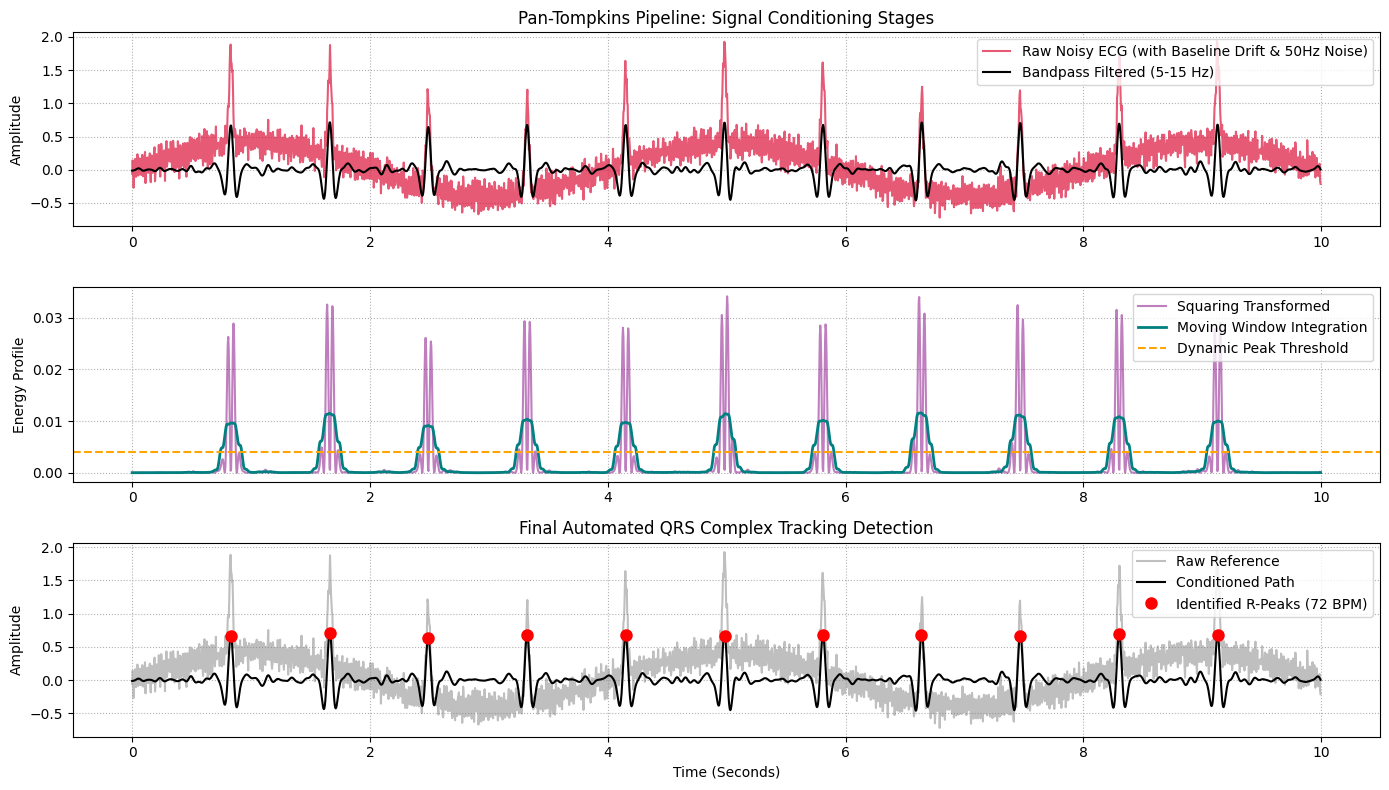

In [1]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Noisy ECG Signal ---
fs = 250  # Sampling frequency (Hz)
duration = 10  # Duration in seconds
time = np.arange(int(fs * duration)) / fs

# Simulate a clean heart rate baseline (~72 BPM)
clean_ecg, _ = signal.find_peaks(np.sin(2 * np.pi * 1.2 * time), distance=fs/2)
ecg_raw = np.zeros_like(time)
for p in [int(x*fs*0.83) for x in range(1, 12)]:
    if p < len(time)-20:
        ecg_raw[p:p+3] = [0.3, 1.5, -0.4]  # QRS amplitude spikes

# Convolve to create realistic P and T waves
window = signal.windows.gaussian(25, std=4)
ecg_raw = signal.convolve(ecg_raw, window, mode='same')

# Inject realistic artifacts: Baseline Wander (Low Freq) + Powerline Noise (50 Hz)
baseline_wander = 0.4 * np.sin(2 * np.pi * 0.25 * time)
powerline_noise = 0.15 * np.sin(2 * np.pi * 50 * time)
white_noise = 0.08 * np.random.randn(len(time))
noisy_ecg = ecg_raw + baseline_wander + powerline_noise + white_noise

# --- 2. Pan-Tompkins Algorithm Stages ---

# Stage 2a: Bandpass Filter (5-15 Hz to isolate QRS energy)
lowcut = 5.0
highcut = 15.0
b, a = signal.butter(3, [lowcut / (0.5 * fs), highcut / (0.5 * fs)], btype='band')
filtered_ecg = signal.filtfilt(b, a, noisy_ecg)

# Stage 2b: Derivative Operation (To highlight high-slope regions of R-peak)
b_diff = np.array([2, 1, 0, -1, -2]) / 8.0
derived_ecg = signal.convolve(filtered_ecg, b_diff, mode='same')

# Stage 2c: Squaring Function (Non-linear amplification of QRS complex)
squared_ecg = derived_ecg ** 2

# Stage 2d: Moving Window Integration (Obtain waveform duration info)
window_len = int(0.150 * fs)  # 150ms window
integrated_ecg = signal.convolve(squared_ecg, np.ones(window_len)/window_len, mode='same')

# --- 3. Dynamic Thresholding & R-Peak Detection ---
# Calculate an adaptive threshold based on moving signal envelope averages
peak_threshold = 0.35 * np.max(integrated_ecg)
r_peaks, _ = signal.find_peaks(integrated_ecg, height=peak_threshold, distance=int(0.4 * fs))

# --- 4. Metrics Extraction: Heart Rate Variability (HRV) ---
rr_intervals = np.diff(r_peaks) / fs  # RR intervals in seconds
bpm = 60.0 / np.mean(rr_intervals)
rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2)) * 1000  # RMSSD in milliseconds

print("="*45)
print(f"📊 EXTRACTED BIOMETRIC METRICS:")
print(f"  • Mean Heart Rate : {bpm:.2f} BPM")
print(f"  • HRV Metric (RMSSD): {rmssd:.2f} ms")
print("="*45)

# --- 5. Diagnostic Pipeline Visualization ---
plt.figure(figsize=(14, 8))

# Subplot 1: Raw vs Filtered ECG Signals
plt.subplot(3, 1, 1)
plt.plot(time, noisy_ecg, label='Raw Noisy ECG (with Baseline Drift & 50Hz Noise)', color='crimson', alpha=0.7)
plt.plot(time, filtered_ecg, label='Bandpass Filtered (5-15 Hz)', color='black', lw=1.5)
plt.title('Pan-Tompkins Pipeline: Signal Conditioning Stages')
plt.ylabel('Amplitude')
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

# Subplot 2: Non-linear Mathematical Pipeline Transformations
plt.subplot(3, 1, 2)
plt.plot(time, squared_ecg, label='Squaring Transformed', color='purple', alpha=0.5)
plt.plot(time, integrated_ecg, label='Moving Window Integration', color='teal', lw=2)
plt.axhline(peak_threshold, color='orange', linestyle='--', label='Dynamic Peak Threshold')
plt.ylabel('Energy Profile')
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

# Subplot 3: Final Output Tracking Identification
plt.subplot(3, 1, 3)
plt.plot(time, noisy_ecg, color='gray', alpha=0.5, label='Raw Reference')
plt.plot(time, filtered_ecg, color='black', label='Conditioned Path')
plt.plot(r_peaks / fs, filtered_ecg[r_peaks], "ro", markersize=8, label=f'Identified R-Peaks ({int(bpm)} BPM)')
plt.title('Final Automated QRS Complex Tracking Detection')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('pan_tompkins_performance.png', dpi=300)
plt.show()